In [1]:
import sys
sys.path.append("..")
import pandas as pd
import src.config as config

In [2]:
import src.plot.plotter as plotter

## Load energy mix data

In [3]:
dc_name = "aws_Dublin"

data_path = f"../data/experiments/{config.d_i}-{config.d_f}/raw/{dc_name}/energy_mix/"

in_historical = f"{data_path}historical.csv"
in_forecast = f"{data_path}forecast.csv"

In [4]:
df = pd.read_csv(in_historical)
forecast_df = pd.read_csv(in_forecast)

In [5]:
renewable_sources = ['wind', 'solar', 'hydro', 'geothermal', 'biomass']
non_renewable_sources = ['nuclear', 'coal', 'gas', 'oil', 'unknown']

In [6]:
# Total actual and forecast renewables
actual_renewables = df[renewable_sources].sum(axis=1)
forecast_renewables = forecast_df[renewable_sources].sum(axis=1)

# Compute MAE and relative MAE
mae = (forecast_renewables - actual_renewables).abs().mean()
mae_percent = mae / actual_renewables.mean() * 100

print(f"Renewable Forecast MAE: {mae:.2f} MW ")
print(f"Relative MAE: {mae_percent:.2f}%")



Renewable Forecast MAE: 86.46 MW 
Relative MAE: 6.02%


## Plotting

In [7]:
from src.plot.colors import IBM_color_blind_palette

sources_color_ren = {
    'wind': IBM_color_blind_palette[0],
    'solar': IBM_color_blind_palette[1],
    'hydro': IBM_color_blind_palette[2],
    'geothermal': IBM_color_blind_palette[3],
    'biomass': IBM_color_blind_palette[4],
}

['wind', 'solar', 'hydro', 'geothermal', 'biomass']

sources_color_non_ren = {
    'gas': IBM_color_blind_palette[0],
    'coal': IBM_color_blind_palette[1],
    'nuclear': IBM_color_blind_palette[2],
    'oil': IBM_color_blind_palette[3],
    'unknown': IBM_color_blind_palette[4]
}

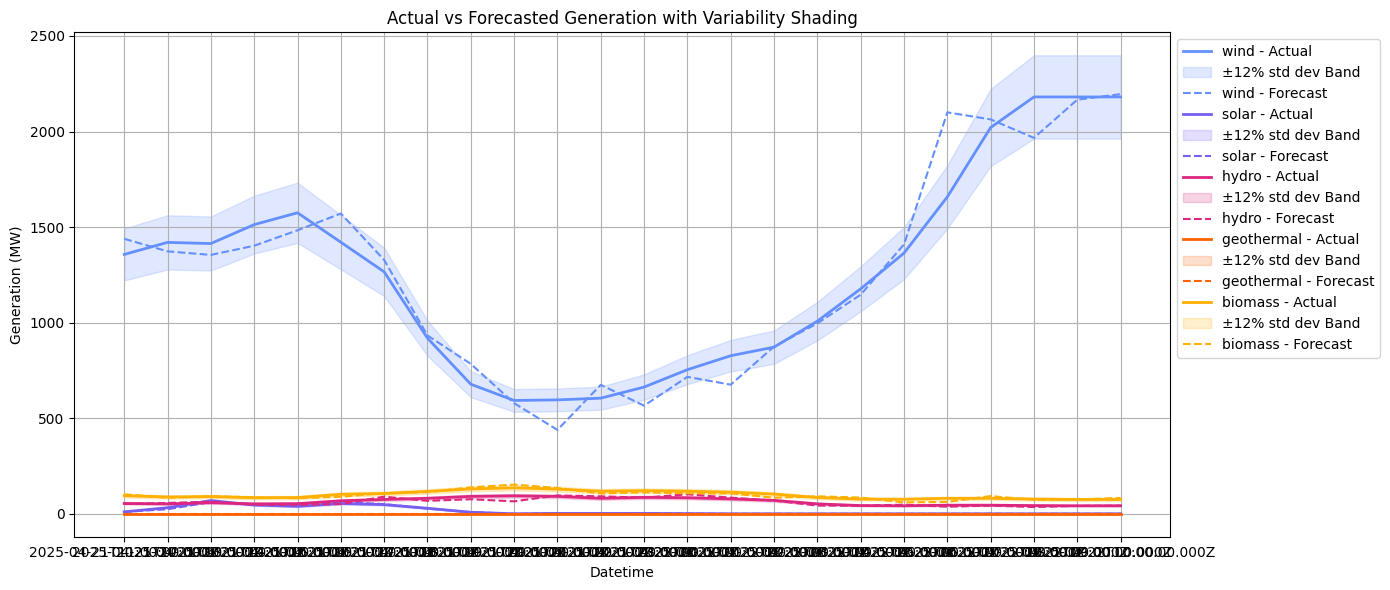

In [8]:
plotter.plot_sources_with_shaded_area(df, forecast_df, sources=sources_color_ren)

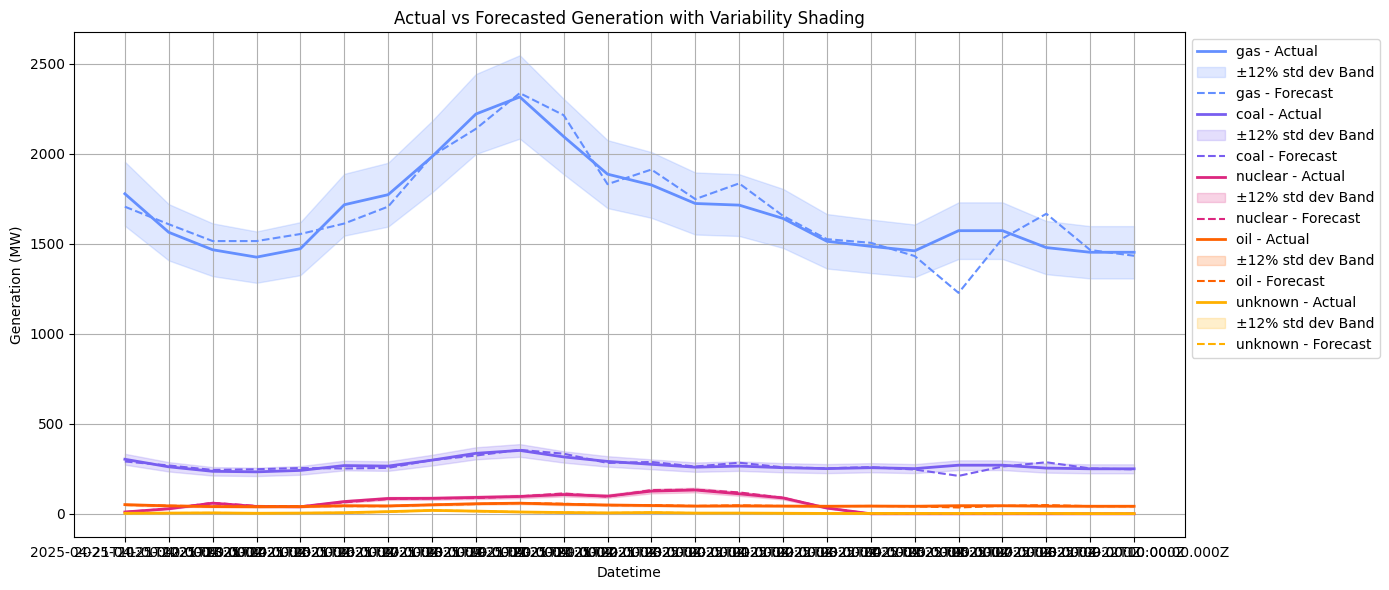

In [9]:

plotter.plot_sources_with_shaded_area(df, forecast_df, sources=sources_color_non_ren)

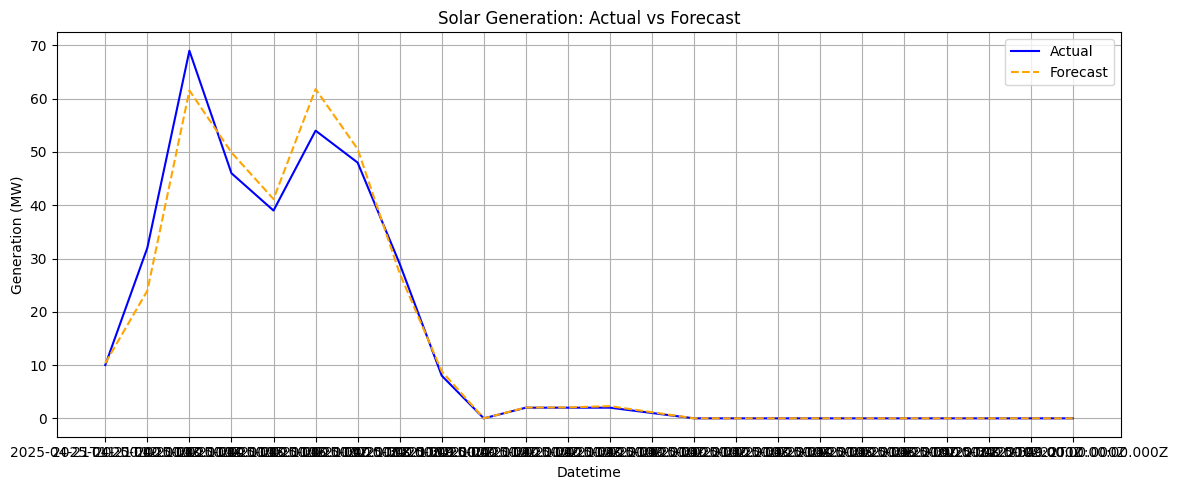

In [10]:

plotter.plot_forecast_vs_actual(df_actual=df, df_forecast=forecast_df, source="solar")
